Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle


 STEP 2: Upload and Load Dataset

Upload CSV File From Your local system



In [ ]:
from google.colab import files
uploaded = files.upload()

Loadin The Dataset of Matches

In [4]:
matches = pd.read_csv('matches.csv')


In [197]:
matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
matches.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
count,636.000000,636.000000,636.000000,636.000000,636.000000,0.0
mean,318.500000,2012.490566,0.025157,13.682390,3.372642,NaN
std,183.741666,2.773026,0.156726,23.908877,3.420338,NaN
min,1.000000,2008.000000,0.000000,0.000000,0.000000,NaN
25%,159.750000,2010.000000,0.000000,0.000000,0.000000,NaN
50%,318.500000,2012.000000,0.000000,0.000000,4.000000,NaN
75%,477.250000,2015.000000,0.000000,20.000000,7.000000,NaN
max,636.000000,2017.000000,1.000000,146.000000,10.000000,NaN


STEP 3: Data Cleaning

 Droping the irrelevant columns

In [6]:
matches.drop(['umpire1', 'umpire2', 'umpire3', 'result', 'dl_applied', 'id'], axis=1, inplace=True)

Drop rows where 'winner' is null

In [8]:
matches.dropna(subset=['winner'], inplace=True)

Standardize team names

In [9]:
matches.replace({'Kings XI Punjab': 'Punjab Kings', 'Delhi Daredevils': 'Delhi Capitals'}, inplace=True)

In [13]:
print(matches.columns.tolist())

['season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue']


In [16]:
matches['season'] = matches['season'].astype(str).str.extract(r'(\d+)').astype(int)
matches = matches[matches['season'] <= 2019]


STEP 4: Visualizations (EDA)

Matches per Season

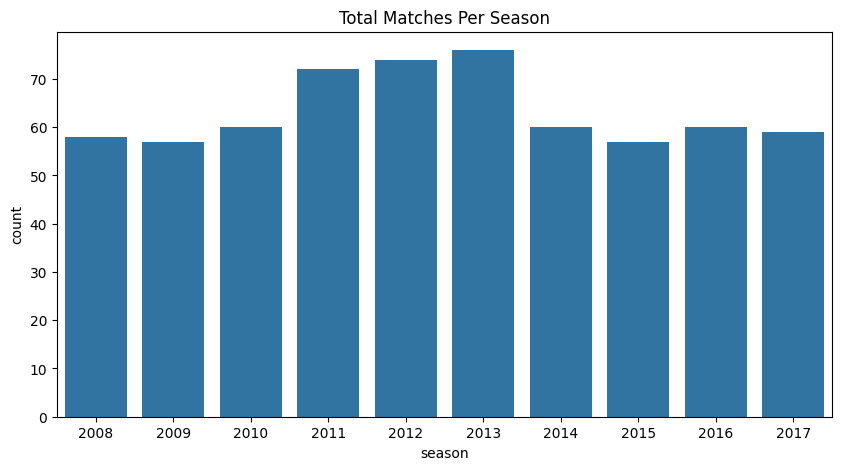

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(data=matches, x='season')

plt.title("Total Matches Per Season")

plt.show()

🟩 Wins per Team

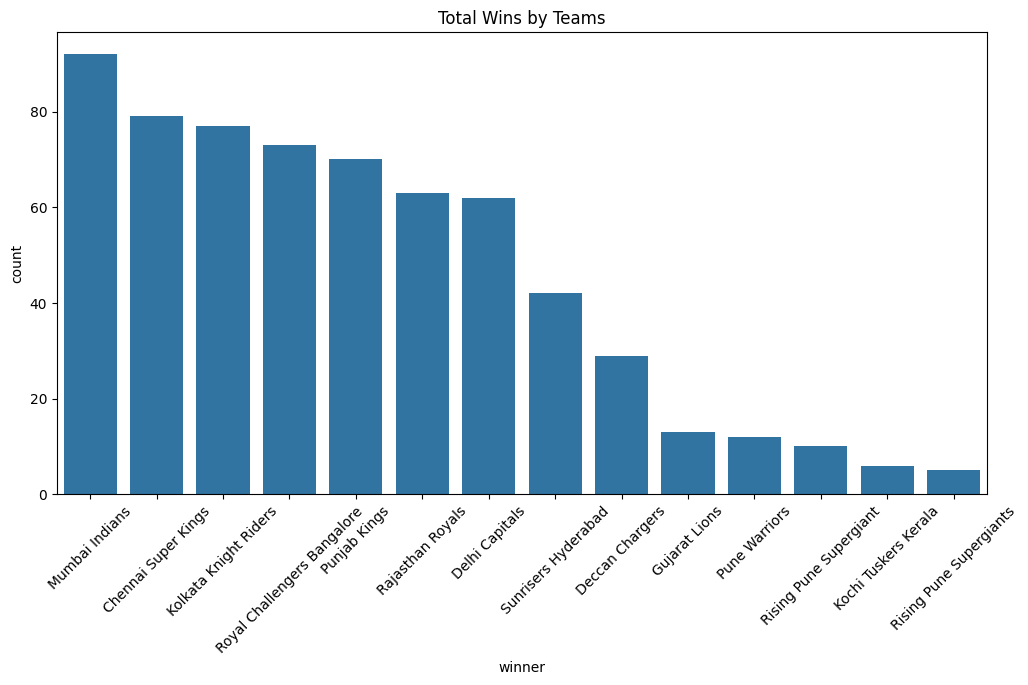

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=matches, x='winner', order=matches['winner'].value_counts().index)
plt.title("Total Wins by Teams")
plt.xticks(rotation=45)
plt.show()


STEP 5: Prepare Features

In [22]:
df = matches[['season', 'team1', 'team2', 'toss_winner', 'venue', 'city', 'winner']]


 STEP 6: Encode Data (OneHotEncoder)

In [23]:
X = df.drop('winner', axis=1)
y = df['winner']

categorical_cols = ['team1', 'team2', 'toss_winner', 'venue', 'city']

# One-hot encoding for categorical columns
# Added handle_unknown='ignore' to the OneHotEncoder
ct = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

X_encoded = ct.fit_transform(X)


 STEP 7: Train-Test Split & Model Training

In [24]:
from sklearn.impute import SimpleImputer

# Impute missing values in the encoded features
# Use mean imputation as an example, you might choose a different strategy
imputer = SimpleImputer(strategy='mean')
X_encoded_imputed = imputer.fit_transform(X_encoded)


X_train, X_test, y_train, y_test = train_test_split(X_encoded_imputed, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

STEP 8: Evaluation

In [25]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5118110236220472

Classification Report:
                              precision    recall  f1-score   support

        Chennai Super Kings       0.57      0.55      0.56        22
            Deccan Chargers       0.00      0.00      0.00         6
             Delhi Capitals       0.50      0.78      0.61         9
              Gujarat Lions       1.00      0.33      0.50         3
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.65      0.68      0.67        19
             Mumbai Indians       0.50      0.50      0.50        16
              Pune Warriors       0.00      0.00      0.00         2
               Punjab Kings       0.50      0.44      0.47        16
           Rajasthan Royals       0.36      0.50      0.42         8
     Rising Pune Supergiant       1.00      0.67      0.80         3
Royal Challengers Bangalore       0.47      0.44      0.45        16
        Sunrisers Hyderabad       0.50      0.67

C:\Users\DEEPA V Y\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DEEPA V Y\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DEEPA V Y\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

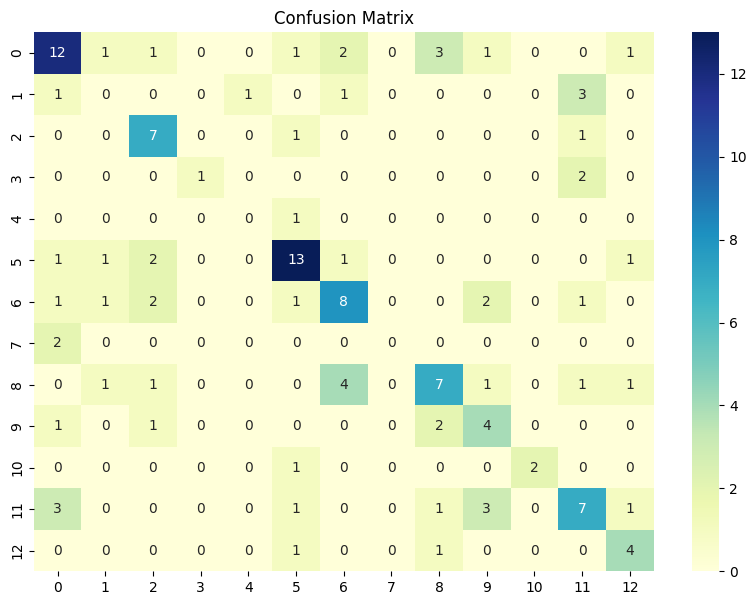

In [26]:
# Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="YlGnBu", fmt='d')
plt.title("Confusion Matrix")
plt.show()


 STEP 9: Predicting Past Champions (2008–2019)

In [30]:
winners = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
Season_winner = winners.sort_values(['season', 'wins'], ascending=[True, False]).drop_duplicates('season')

print(Season_winner)


    season                 winner  wins
6     2008       Rajasthan Royals    13
10    2009         Delhi Capitals    10
20    2010         Mumbai Indians    11
24    2011    Chennai Super Kings    11
37    2012  Kolkata Knight Riders    12
46    2013         Mumbai Indians    13
56    2014           Punjab Kings    12
60    2015    Chennai Super Kings    10
75    2016    Sunrisers Hyderabad    11
79    2017         Mumbai Indians    12


In [33]:
actual_winners_dict = {
    2008: "Rajasthan Royals",
    2009: "Deccan Chargers",
    2010: "Chennai Super Kings",
    2011: "Chennai Super Kings",
    2012: "Kolkata Knight Riders",
    2013: "Mumbai Indians",
    2014: "Kolkata Knight Riders",
    2015: "Mumbai Indians",
    2016: "Sunrisers Hyderabad",
    2017: "Mumbai Indians",
    2018: "Chennai Super Kings",
    2019: "Mumbai Indians"
}

# Create comparison_df from Season_winner and rename the winner column
comparison_df = Season_winner.rename(columns={'winner': 'predicted_winner'})


comparison_df['actual_winner'] = comparison_df['season'].map(actual_winners_dict)

# Add a column to show match status
comparison_df['correct'] = comparison_df['actual_winner'] == comparison_df['predicted_winner']

print(comparison_df[['season', 'actual_winner', 'predicted_winner', 'correct']])

    season          actual_winner       predicted_winner  correct
6     2008       Rajasthan Royals       Rajasthan Royals     True
10    2009        Deccan Chargers         Delhi Capitals    False
20    2010    Chennai Super Kings         Mumbai Indians    False
24    2011    Chennai Super Kings    Chennai Super Kings     True
37    2012  Kolkata Knight Riders  Kolkata Knight Riders     True
46    2013         Mumbai Indians         Mumbai Indians     True
56    2014  Kolkata Knight Riders           Punjab Kings    False
60    2015         Mumbai Indians    Chennai Super Kings    False
75    2016    Sunrisers Hyderabad    Sunrisers Hyderabad     True
79    2017         Mumbai Indians         Mumbai Indians     True


🏆 Model Accuracy on Past IPL Champions (2008–2019): 60.00%


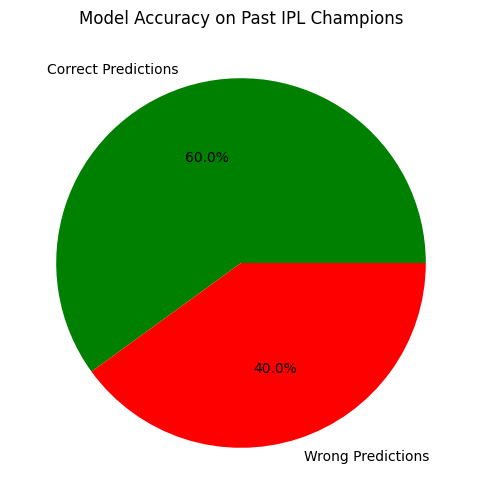

In [34]:
correct_preds = comparison_df['correct'].sum()
total_preds = comparison_df.shape[0]

accuracy = (correct_preds / total_preds) * 100
print(f"🏆 Model Accuracy on Past IPL Champions (2008–2019): {accuracy:.2f}%")

# Pie Chart to show correct vs incorrect
labels = ['Correct Predictions', 'Wrong Predictions']
values = [correct_preds, total_preds - correct_preds]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Model Accuracy on Past IPL Champions")
plt.show()


STEP 10: Simulate IPL 2025 Final – Custom Input

In [36]:
# Simulate 2025 Final: RCB vs PBK

final_2025 = pd.DataFrame({
    'team1': ['Royal Challengers Bangalore'],
    'team2': ['Punjab Kings'],
    'toss_winner': ['Punjab Kings'],
    'venue': ['Narendra Modi Stadium'],
    'city': ['Ahmedabad'],
    'season': [2025]
})

final_encoded = ct.transform(final_2025)

prediction = model.predict(final_encoded)

print("🏆 Predicted 2025 IPL Winner:", prediction[0])

🏆 Predicted 2025 IPL Winner: Punjab Kings


C:\Users\DEEPA V Y\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


STEP 11: Save the Model

In [38]:
pickle.dump(model, open('ipl_model.pkl', 'wb'))
pickle.dump(ct, open('transform.pkl', 'wb'))
print("✅ Model and Transformer Saved Successfully.")

✅ Model and Transformer Saved Successfully.
